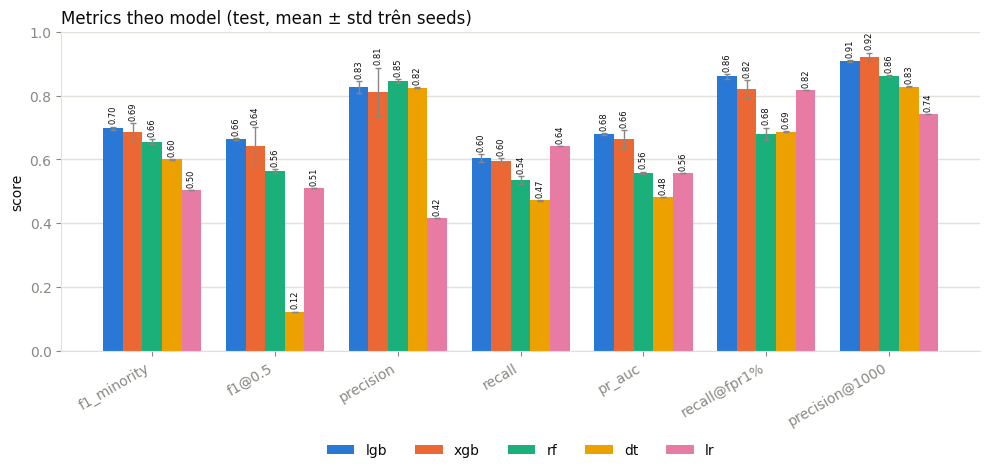

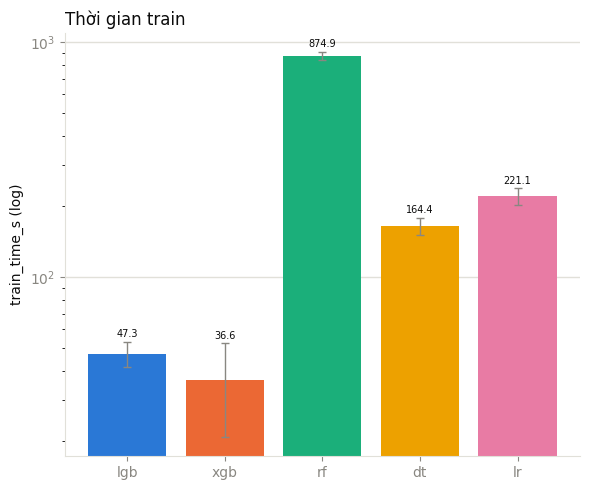

,n_seeds,f1_minority,f1@0.5,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,,
lgb,4,0.6979 ± 0.005,0.6631 ± 0.0033,0.8274 ± 0.018,0.6037 ± 0.0129,0.6798 ± 0.0024,0.8605 ± 0.0071,0.9082 ± 0.0019,47.3 ± 5.9
xgb,4,0.6869 ± 0.0279,0.6415 ± 0.0593,0.8125 ± 0.0751,0.5966 ± 0.0066,0.6638 ± 0.0286,0.8204 ± 0.0283,0.922 ± 0.0128,36.6 ± 15.7
rf,4,0.6554 ± 0.0079,0.5625 ± 0.0064,0.8454 ± 0.007,0.5353 ± 0.0128,0.5579 ± 0.0043,0.6803 ± 0.0194,0.861 ± 0.0022,874.9 ± 32.3
dt,4,0.6008 ± 0.0012,0.1233 ± 0.0004,0.8246 ± 0.0012,0.4726 ± 0.0011,0.4821 ± 0.001,0.6866 ± 0.0017,0.8278 ± 0.001,164.4 ± 13.9
lr,4,0.5049 ± 0.0,0.5108 ± 0.0,0.4166 ± 0.0,0.6407 ± 0.0,0.5582 ± 0.0,0.8176 ± 0.0,0.743 ± 0.0,221.1 ± 17.4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ["f1_minority", "f1@0.5", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS = {"train_time_s": 1}

df = pd.read_csv("results.csv")
n0 = len(df)
df = df.drop_duplicates(subset=["model", "split", "seed"], keep="last")
if n0 != len(df):
    print(f"bỏ {n0 - len(df)}")

test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

order = mean["f1_minority"].sort_values(ascending=False).index
tbl = tbl.loc[order]
tbl.index.name = "model (test)"

# --- vẽ ---
SCORE_METRICS = ["f1_minority", "f1@0.5", "precision", "recall",
                  "pr_auc", "recall@fpr1%", "precision@1000"]
MODEL_COLOR = {
    "lgb": "#2a78d6", "xgb": "#eb6834", "rf": "#1baf7a",
    "dt": "#eda100", "lr": "#e87ba4",
}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
models = list(order)

# --- hình 1: scores theo metric ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(SCORE_METRICS))
width = 0.8 / len(models)
for i, m in enumerate(models):
    color = MODEL_COLOR.get(m, "#898781")
    vals = mean.loc[m, SCORE_METRICS].to_numpy()
    errs = std.loc[m, SCORE_METRICS].to_numpy()
    bars = ax1.bar(x + i * width, vals, width, yerr=errs, capsize=2,
                    color=color, label=m, edgecolor="none", error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax1.bar_label(bars, labels=[f"{v:.2f}" for v in vals], padding=2, fontsize=6, color=INK)

ax1.set_xticks(x + width * (len(models) - 1) / 2)
ax1.set_xticklabels(SCORE_METRICS, rotation=30, ha="right", color=INK)
ax1.set_ylim(0, 1)
ax1.set_ylabel("score", color=INK)
ax1.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax1.set_axisbelow(True)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax1.spines[spine].set_color(GRID)
ax1.tick_params(colors=MUTED)
ax1.set_title("Metrics theo model (test, mean ± std trên seeds)", color=INK, loc="left")
ax1.legend(frameon=False, ncol=len(models), loc="upper center",
           bbox_to_anchor=(0.5, -0.25), labelcolor=INK)
plt.tight_layout()
plt.show()

# --- hình 2: thời gian train ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
for i, m in enumerate(models):
    color = MODEL_COLOR.get(m, "#898781")
    t = mean.loc[m, "train_time_s"]
    bar2 = ax2.bar(i, t, yerr=std.loc[m, "train_time_s"],
                    capsize=3, color=color, edgecolor="none",
                    error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax2.bar_label(bar2, labels=[f"{t:.1f}"], padding=2, fontsize=7, color=INK)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, color=INK)
ax2.set_yscale("log")
ax2.set_ylabel("train_time_s (log)", color=INK)
ax2.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax2.set_axisbelow(True)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax2.spines[spine].set_color(GRID)
ax2.tick_params(colors=MUTED)
ax2.set_title("Thời gian train", color=INK, loc="left")
plt.tight_layout()
plt.show()

tbl

In [ ]:
import pandas as pd

METRICS = ["f1_minority", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS = {"train_time_s": 1}

df = pd.read_csv("results-gnn.csv")
n0 = len(df)
df = df.drop_duplicates(subset=["model", "split", "seed"], keep="last")
if n0 != len(df):
    print(f"Da bo {n0 - len(df)} dong trung theo (model, split, seed), giu lan chay cuoi.")

test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

tbl = tbl.loc[mean["f1_minority"].sort_values(ascending=False).index]
tbl.index.name = "model (test)"
tbl

,n_seeds,f1_minority,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,
sage_noedge,4,0.484 ± 0.0094,0.554 ± 0.0144,0.4299 ± 0.0119,0.4257 ± 0.0145,0.7524 ± 0.0099,0.6423 ± 0.0112,108.4 ± 5.6
sage,4,0.4656 ± 0.0089,0.5507 ± 0.0206,0.4038 ± 0.0154,0.4213 ± 0.0089,0.725 ± 0.0197,0.6295 ± 0.0039,138.3 ± 8.9


In [3]:
import pandas as pd
METRICS=["f1_minority", "precision", "recall","pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS={"train_time":1}
df_gnn = pd.read_csv("results-gnn.csv")
df_lstm = pd.read_csv("results-LSTM.csv")
df = pd.concat([df_gnn, df_lstm], ignore_index=True)
test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

tbl = tbl.loc[mean["f1_minority"].sort_values(ascending=False).index]
tbl.index.name = "model (test)"
tbl

,n_seeds,f1_minority,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,
sage_lstm,4,0.5049 ± 0.0203,0.5914 ± 0.0449,0.4454 ± 0.053,0.493 ± 0.0281,0.766 ± 0.0215,0.6905 ± 0.0348,317.6 ± 12.2521
sage_noedge_lstm,4,0.4877 ± 0.0095,0.5808 ± 0.0236,0.4217 ± 0.0266,0.4538 ± 0.0123,0.7664 ± 0.0132,0.6528 ± 0.0128,288.625 ± 10.1438
sage_noedge,4,0.484 ± 0.0094,0.554 ± 0.0144,0.4299 ± 0.0119,0.4257 ± 0.0145,0.7524 ± 0.0099,0.6423 ± 0.0112,108.45 ± 5.5752
sage,4,0.4656 ± 0.0089,0.5507 ± 0.0206,0.4038 ± 0.0154,0.4213 ± 0.0089,0.725 ± 0.0197,0.6295 ± 0.0039,138.325 ± 8.8947


In [ ]:
import pandas as pd

for name in ["train", "val", "test"]:
    df = pd.read_parquet(f"dataset_high/edge_attr_{name}.parquet", columns=["seen_before"])
    cold = 1 - df["seen_before"].mean()
    print(f"{name:5s}: n_edges={len(df):>9,} | cold-start (seen_before=0) = {cold*100:5.2f}%")